# Weight diagnostics plots (entropy & ESS)

Reads CSV files from `weight_diagnostics/sctab/{seed}/scvi/` and plots:
1. Normalized entropy vs training epoch (separate figure, one panel per atlas count)
2. Normalized ESS vs training epoch (separate figure, one panel per atlas count)
3. Entropy vs ESS scatter colored by epoch
4. Heatmap of ESS across epoch × atlas count

Reference: uniform sampling (Standard) → `entropy_normalized = 1`, `ess_normalized = 1`.

In [1]:
import os
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

In [2]:
# --- configuration ---
base_dir = ('/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications'
            '/rebuttal/new_results/scvi/weight_diagnostics/sctab/')
model_name = 'scvi'
atlas_counts_to_plot = [0, 1, 10, 100, 1000, 10000, 50000]  # subset for line plots; set to None to plot all found

output_dir = '../figures/weight_diagnostics'
os.makedirs(output_dir, exist_ok=True)

In [3]:
FNAME_RE = re.compile(
    r'^weight_diagnostics_(?P<data>[^_]+)_AR_epoch\d+_seed(?P<seed>\d+)_'
    r'(?P<model_name>\w+)_ldim\d+_atlascount(?P<atlas_count>\d+)_trackedepoch(?P<tracked_epoch>\w+)\.csv$'
)


def tracked_epoch_sort_key(epoch):
    return int(epoch) if str(epoch) != 'best' else 10_000


def tracked_epoch_label(epoch):
    return 'best' if str(epoch) == 'best' else str(int(epoch))


def load_weight_diagnostics(base_dir, model_name='scvi'):
    """Loop over seed directories and load all diagnostics CSV files."""
    records = []

    for seed_name in sorted(os.listdir(base_dir)):
        seed_dir = os.path.join(base_dir, seed_name, model_name)
        if not os.path.isdir(seed_dir):
            continue

        for fname in sorted(os.listdir(seed_dir)):
            if not fname.endswith('.csv'):
                continue

            m = FNAME_RE.match(fname)
            if m is None:
                print(f'Warning: skipping unrecognized filename: {fname}')
                continue

            full_path = os.path.join(seed_dir, fname)
            df_one = pd.read_csv(full_path)
            tracked_epoch = m.group('tracked_epoch')

            records.append({
                'data': m.group('data'),
                'seed': int(m.group('seed')),
                'atlas_count': int(m.group('atlas_count')),
                'tracked_epoch': tracked_epoch_label(tracked_epoch),
                'epoch_order': tracked_epoch_sort_key(tracked_epoch),
                'entropy_normalized': float(df_one['entropy_normalized'].iloc[0]),
                'ess': float(df_one['ess'].iloc[0]),
                'ess_normalized': float(df_one['ess_normalized'].iloc[0]),
                'path': full_path,
            })

    return pd.DataFrame(records)


metrics_df = load_weight_diagnostics(base_dir, model_name=model_name)

epoch_meta = (
    metrics_df[['tracked_epoch', 'epoch_order']]
    .drop_duplicates()
    .sort_values('epoch_order')
)
tracked_epochs = epoch_meta['tracked_epoch'].tolist()

print(f'Total files loaded: {len(metrics_df)}')
print(f'Seeds: {sorted(metrics_df["seed"].unique())}')
print(f'Atlas counts: {sorted(metrics_df["atlas_count"].unique())}')
print(f'Tracked epochs: {tracked_epochs}')
display(metrics_df.head())

Total files loaded: 560
Seeds: [42, 43, 44, 45, 46]
Atlas counts: [0, 1, 10, 100, 1000, 10000, 50000]
Tracked epochs: ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180', '200', '220', '240', '260', '280', 'best']


,data,seed,atlas_count,tracked_epoch,epoch_order,entropy_normalized,ess,ess_normalized,path
0,sctab,42,0,0,0,0.863946,6558.766934,0.072875,/Users/zeinab/Documents/MSR_internship/manuscr...
1,sctab,42,0,100,100,0.906909,14775.823664,0.164176,/Users/zeinab/Documents/MSR_internship/manuscr...
2,sctab,42,0,120,120,0.905809,14353.497653,0.159483,/Users/zeinab/Documents/MSR_internship/manuscr...
3,sctab,42,0,140,140,0.904758,13933.545177,0.154817,/Users/zeinab/Documents/MSR_internship/manuscr...
4,sctab,42,0,160,160,0.903659,13465.486596,0.149617,/Users/zeinab/Documents/MSR_internship/manuscr...


In [4]:
if atlas_counts_to_plot is not None:
    plot_df = metrics_df[metrics_df['atlas_count'].isin(atlas_counts_to_plot)].copy()
else:
    plot_df = metrics_df.copy()

print(f'Rows selected for plotting: {len(plot_df)}')
print(f'Atlas counts in plots: {sorted(plot_df["atlas_count"].unique())}')

Rows selected for plotting: 560
Atlas counts in plots: [0, 1, 10, 100, 1000, 10000, 50000]


In [5]:
# Quick summary of loaded diagnostics
summary = (
    metrics_df.groupby(['atlas_count', 'tracked_epoch', 'epoch_order'], as_index=False)
    .agg(
        n_seeds=('seed', 'nunique'),
        entropy_mean=('entropy_normalized', 'mean'),
        ess_norm_mean=('ess_normalized', 'mean'),
    )
    .sort_values(['atlas_count', 'epoch_order'])
)
display(summary.head(12))

,atlas_count,tracked_epoch,epoch_order,n_seeds,entropy_mean,ess_norm_mean
0,0,0,0,5,0.866267,0.075018
6,0,20,20,5,0.907676,0.153368
12,0,40,40,5,0.911215,0.159184
13,0,60,60,5,0.909590,0.160989
14,0,80,80,5,0.909314,0.162487
1,0,100,100,5,0.909293,0.162690
2,0,120,120,5,0.908509,0.162325
3,0,140,140,5,0.907810,0.159331
4,0,160,160,5,0.907022,0.155519
5,0,180,180,5,0.905257,0.149708


In [6]:
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

UNIFORM_REF = 1.0
epoch_labels = [tracked_epoch_label(e) for e in tracked_epochs]
epoch_to_x = {label: i for i, label in enumerate(epoch_labels)}
x_pos = np.arange(len(tracked_epochs))


def aggregate_by_epoch(sub_df, value_col):
    agg = (
        sub_df.groupby(['tracked_epoch', 'epoch_order'], as_index=False)[value_col]
        .agg(mean='mean', std='std', count='count')
        .sort_values('epoch_order')
    )
    agg['x'] = agg['tracked_epoch'].map(epoch_to_x)
    return agg


def grid_shape(n_panels, max_cols=4):
    ncols = min(max_cols, n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    return nrows, ncols


def plot_metric_by_atlas(
    plot_df,
    metric,
    ylabel,
    color,
    title,
    filename,
    max_cols=4,
):
    """One figure per metric; each atlas count gets its own panel."""
    atlas_values = sorted(plot_df['atlas_count'].unique())
    n_atlas = len(atlas_values)
    nrows, ncols = grid_shape(n_atlas, max_cols=max_cols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.0 * ncols, 3.6 * nrows),
        sharex=True, sharey=True,
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, atlas_count in enumerate(atlas_values):
        ax = axes_flat[i]
        sub_atlas = plot_df[plot_df['atlas_count'] == atlas_count]
        agg = aggregate_by_epoch(sub_atlas, metric)

        for seed in sorted(sub_atlas['seed'].unique()):
            seed_sub = sub_atlas[sub_atlas['seed'] == seed].sort_values('epoch_order')
            xs = seed_sub['tracked_epoch'].map(epoch_to_x)
            ax.plot(xs, seed_sub[metric], color=color, alpha=0.18, linewidth=1.2)

        ax.fill_between(
            agg['x'], agg['mean'] - agg['std'], agg['mean'] + agg['std'],
            color=color, alpha=0.20, linewidth=0,
        )
        ax.plot(
            agg['x'], agg['mean'], '-o', color=color, linewidth=2.2, markersize=5,
            markerfacecolor='white', markeredgewidth=1.8, label='Mean ± SD',
        )
        ax.axhline(
            UNIFORM_REF, color='#666666', linestyle='--', linewidth=1.5,
            label='Uniform (Standard)',
        )

        ax.set_ylim(-0.02, 1.05)
        ax.set_title(f'Atlas count = {atlas_count:,}', fontsize=11, fontweight='bold')
        if i % ncols == 0:
            ax.set_ylabel(ylabel, fontsize=11)

    for j in range(n_atlas, len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[:n_atlas]:
        ax.set_xticks(x_pos)
        ax.set_xticklabels(epoch_labels, rotation=45, ha='right', fontsize=8)

    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel('Training epoch (checkpoint)', fontsize=10)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9, framealpha=0.9)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()

    out_path = os.path.join(output_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {out_path}')

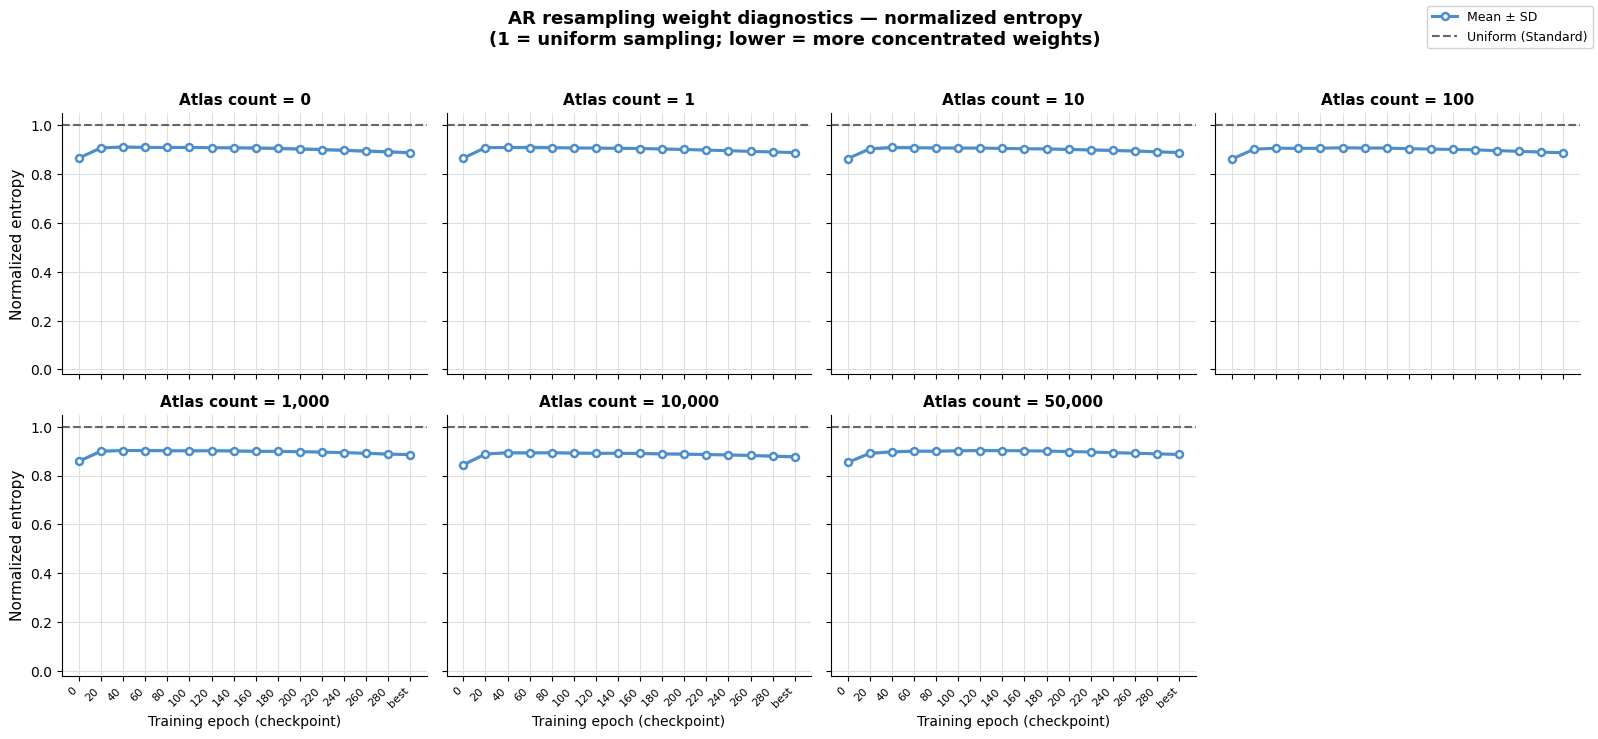

Saved: ../figures/weight_diagnostics/weight_diagnostics_entropy_by_atlas.png


In [7]:
# --- Plot 1: normalized entropy vs epoch (one panel per atlas count) ---
plot_metric_by_atlas(
    plot_df,
    metric='entropy_normalized',
    ylabel='Normalized entropy',
    color='#4C8ECC',
    title='AR resampling weight diagnostics — normalized entropy\n'
           '(1 = uniform sampling; lower = more concentrated weights)',
    filename='weight_diagnostics_entropy_by_atlas.png',
    max_cols=4,
)

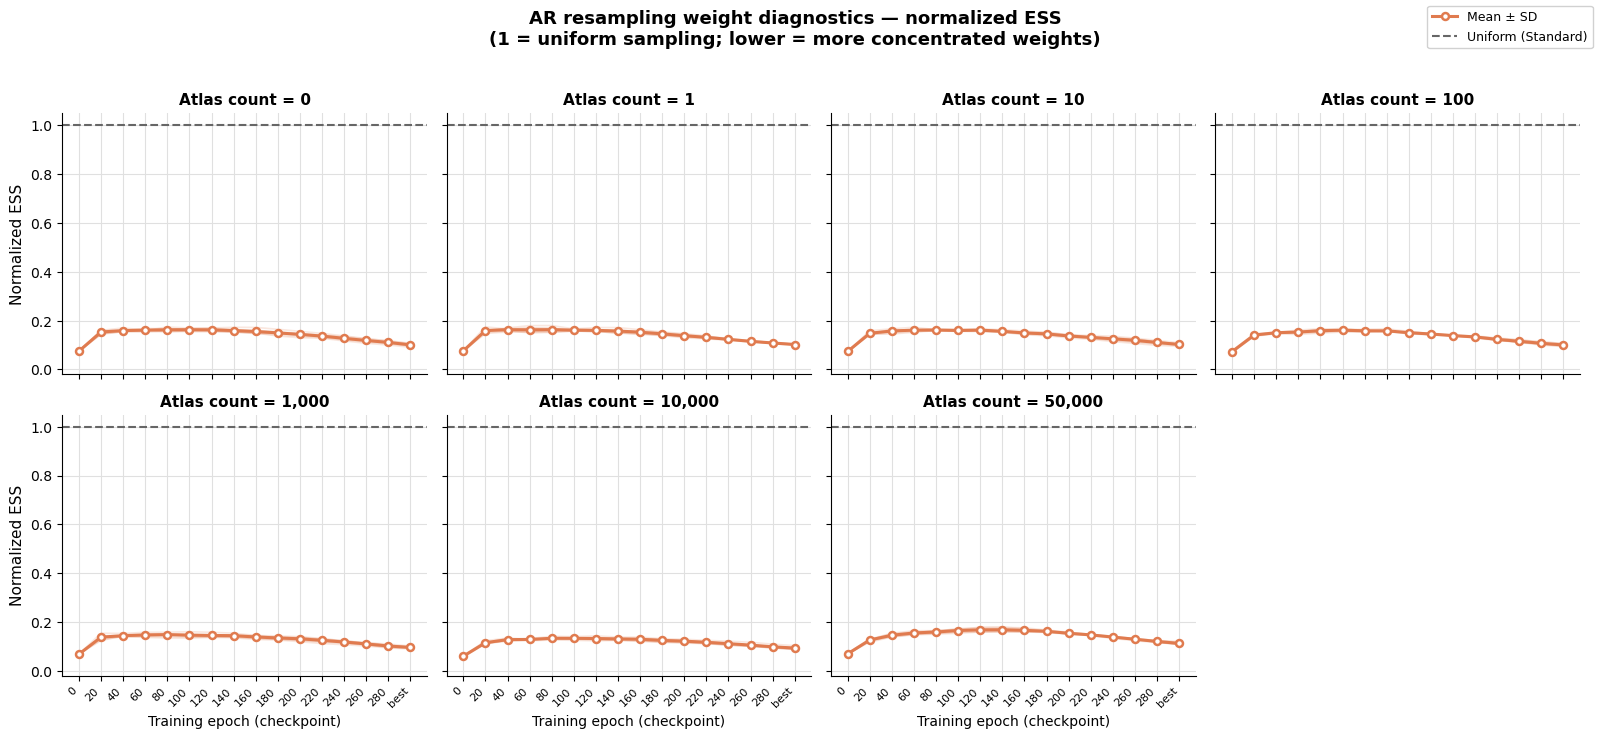

Saved: ../figures/weight_diagnostics/weight_diagnostics_ess_by_atlas.png


In [8]:
# --- Plot 2: normalized ESS vs epoch (one panel per atlas count) ---
plot_metric_by_atlas(
    plot_df,
    metric='ess_normalized',
    ylabel='Normalized ESS',
    color='#E07B4F',
    title='AR resampling weight diagnostics — normalized ESS\n'
           '(1 = uniform sampling; lower = more concentrated weights)',
    filename='weight_diagnostics_ess_by_atlas.png',
    max_cols=4,
)

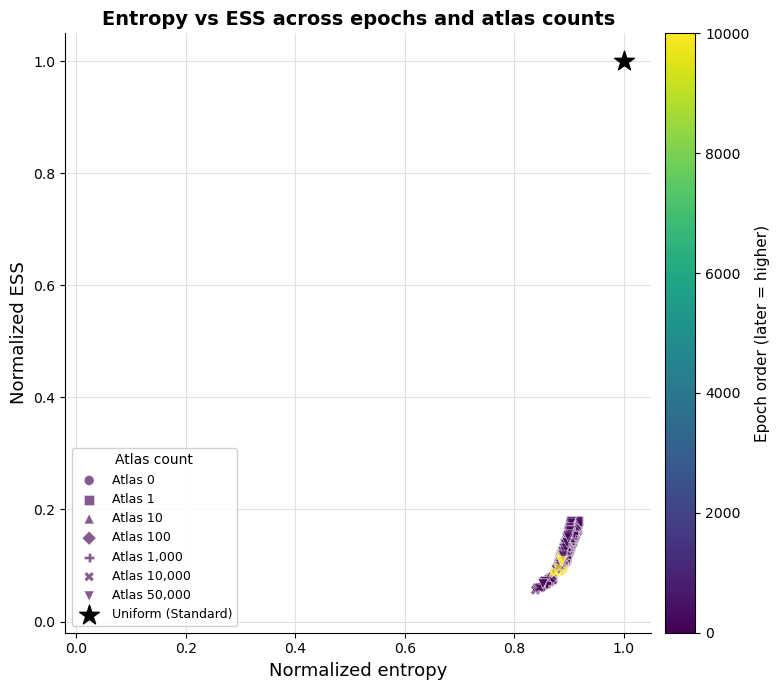

Saved: ../figures/weight_diagnostics/weight_diagnostics_entropy_vs_ess.png


In [15]:
# --- Plot 3: entropy vs ESS scatter (color = epoch, marker = atlas count) ---
atlas_values = sorted(plot_df['atlas_count'].unique())
scatter_df = plot_df.copy()
norm = mpl.colors.Normalize(vmin=0, vmax=max(scatter_df['epoch_order']))
markers = ['o', 's', '^', 'D', 'P', 'X', 'v']

fig, ax = plt.subplots(figsize=(8, 7))
for i, atlas_count in enumerate(atlas_values):
    sub = scatter_df[scatter_df['atlas_count'] == atlas_count]
    sc = ax.scatter(
        sub['entropy_normalized'], sub['ess_normalized'],
        c=sub['epoch_order'], cmap='viridis', norm=norm,
        marker=markers[i % len(markers)],
        s=50, alpha=0.65, edgecolors='white', linewidths=0.4,
        label=f'Atlas {atlas_count:,}',
    )

ax.scatter([UNIFORM_REF], [UNIFORM_REF], marker='*', s=220, c='black',
           zorder=6, label='Uniform (Standard)')
ax.set_xlabel('Normalized entropy', fontsize=13)
ax.set_ylabel('Normalized ESS', fontsize=13)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.set_title('Entropy vs ESS across epochs and atlas counts', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9, title='Atlas count')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Epoch order (later = higher)', fontsize=11)
plt.tight_layout()
out_path = os.path.join(output_dir, 'weight_diagnostics_entropy_vs_ess.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')

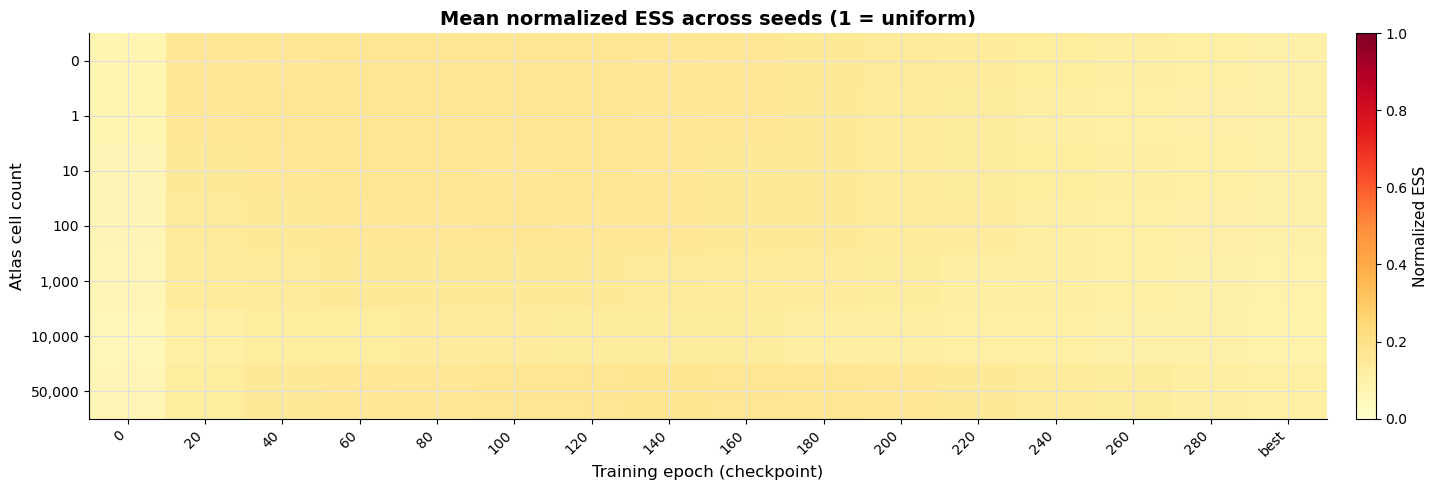

Saved: ../figures/weight_diagnostics/weight_diagnostics_ess_heatmap.png


In [16]:
# --- Plot 4: heatmap of mean normalized ESS (epoch × atlas count) ---
heat_df = (
    metrics_df.groupby(['atlas_count', 'tracked_epoch', 'epoch_order'], as_index=False)
    ['ess_normalized'].mean()
    .sort_values(['atlas_count', 'epoch_order'])
)
pivot = heat_df.pivot(index='atlas_count', columns='tracked_epoch', values='ess_normalized')
pivot = pivot[[tracked_epoch_label(e) for e in tracked_epochs if tracked_epoch_label(e) in pivot.columns]]

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels([f'{v:,}' for v in pivot.index])
ax.set_xlabel('Training epoch (checkpoint)', fontsize=12)
ax.set_ylabel('Atlas cell count', fontsize=12)
ax.set_title('Mean normalized ESS across seeds (1 = uniform)', fontsize=14, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Normalized ESS', fontsize=11)
plt.tight_layout()
out_path = os.path.join(output_dir, 'weight_diagnostics_ess_heatmap.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {out_path}')

In [17]:
# Optional: export aggregated table for supplementary materials
summary_rows = []
for atlas_count in sorted(metrics_df['atlas_count'].unique()):
    sub = metrics_df[metrics_df['atlas_count'] == atlas_count]
    for metric in ['entropy_normalized', 'ess_normalized', 'ess']:
        agg = aggregate_by_epoch(sub, metric)
        for _, row in agg.iterrows():
            summary_rows.append({
                'atlas_count': atlas_count,
                'tracked_epoch': row['tracked_epoch'],
                'metric': metric,
                'mean': row['mean'],
                'std': row['std'],
                'n_seeds': row['count'],
            })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(output_dir, 'weight_diagnostics_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'Saved summary table: {summary_path}')
print(summary_df.head(10))

Saved summary table: ../figures/weight_diagnostics/weight_diagnostics_summary.csv
   atlas_count tracked_epoch              metric      mean       std  n_seeds
0            0             0  entropy_normalized  0.866267  0.001395        5
1            0            20  entropy_normalized  0.907676  0.003211        5
2            0            40  entropy_normalized  0.911215  0.003443        5
3            0            60  entropy_normalized  0.909590  0.002768        5
4            0            80  entropy_normalized  0.909314  0.002898        5
5            0           100  entropy_normalized  0.909293  0.002870        5
6            0           120  entropy_normalized  0.908509  0.002993        5
7            0           140  entropy_normalized  0.907810  0.003323        5
8            0           160  entropy_normalized  0.907022  0.003892        5
9            0           180  entropy_normalized  0.905257  0.004264        5
